In [2]:
import numpy as np
## Experimental results from Lockwood et al. 1980
edep_exp = [1.63,
            1.87,
            2.01,
            2.12,
            2.28,
            2.37,
            2.45,
            2.64,
            2.73,
            2.90,
            2.98,
            3.17,
            3.22,
            3.28,
            3.28,
            3.25,
            3.11,
            2.87,
            2.76,
            2.52,
            2.43,
            1.93,
            1.63,
            1.09,
            0.42,
            0.08
            ]

exp_fmr = [0.0045,
            0.0165,
            0.0317,
            0.0448,
            0.0591,
            0.0707,
            0.0836,
            0.0987,
            0.115,
            0.127,
            0.142,
            0.174,
            0.195,
            0.221,
            0.253,
            0.280,
            0.320,
            0.373,
            0.391,
            0.431,
            0.443,
            0.511,
            0.552,
            0.621,
            0.736,
            0.846]

edep_theo = [1.79,
             1.96,
             2.18,
             2.33,
             2.50,
             2.74,
             2.83,
             3.10,
             3.18,
             3.35,
             3.40,
             3.42,
             3.36,
             3.39,
             3.41,
             3.40,
             3.38,
             3.12,
             2.96,
             2.89,
             2.68,
             2.52,
             2.43,
             2.25,
             2.17,
             2.12,
             1.85,
             1.70,
             1.58,
             1.43,
             1.28,
             1.18,
             1.02,
             0.84,
             0.67,
             0.56,
             0.47,
             0.35,
             0.26,
             0.19,
             0.17,
             0.10,
             0.07,
             0.06,
             0.03,
             0.02,
             0.01]

theo_fmr = [0.02,
            0.04,
            0.06,
            0.08,
            0.10,
            0.12,
            0.14,
            0.16,
            0.18,
            0.20,
            0.22,
            0.24,
            0.26,
            0.28,
            0.30,
            0.32,
            0.34,
            0.36,
            0.38,
            0.40,
            0.42,
            0.44,
            0.46,
            0.48,
            0.50,
            0.52,
            0.54,
            0.56,
            0.58,
            0.60,
            0.62,
            0.64,
            0.66,
            0.68,
            0.70,
            0.72,
            0.74,
            0.76,
            0.78,
            0.80,
            0.82,
            0.84,
            0.86,
            0.88,
            0.90,
            0.92,
            0.94]


In [3]:
print(f"Experimental edep_exp: {sum(edep_exp)}")
print(f"Theoretical edep_theo: {sum(edep_theo)}")
print(f"Experimental lenList: {len(edep_exp)}")
print(f"Theoretical lenList: {len(edep_theo)}")
print(f"norm_exp: {np.sum(edep_exp)/sum(edep_exp)}")
print(f"norm_theo: {np.sum(edep_theo)/sum(edep_theo)}")

Experimental edep_exp: 61.02
Theoretical edep_theo: 86.70000000000002
Experimental lenList: 26
Theoretical lenList: 47
norm_exp: 1.0
norm_theo: 0.9999999999999997


len_exp: 26, len_theo: 47, len_mcdc: 563
MCDC: 0.9999992509847079
Exp: 0.9509517765
Theo: 0.9764039999999999


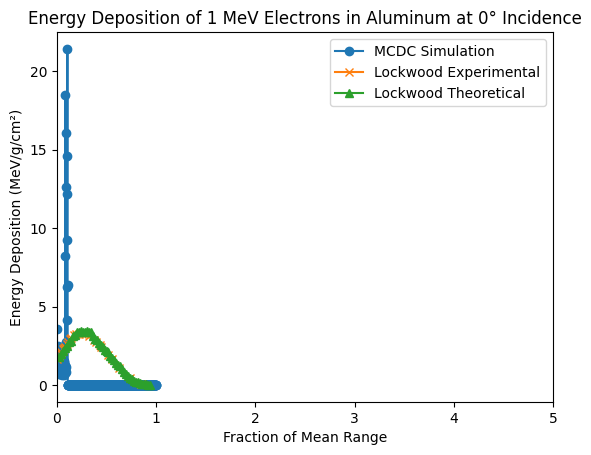

In [ ]:
import h5py
with h5py.File("lockwood_output_20251124_225550.h5", "r") as f:
    z = f["tallies/mesh_tally_0/grid/z"][:]
    dz = z[1:] - z[:-1]
    edep = f["tallies/mesh_tally_0/edep/mean"][:]

M = 5
CSDA_RANGE = 0.569 # g/cm2
# CSDA_RANGE = 0.45 # g/cm2
RHO_G_CM3 = 2.70   # g/cm3
L = (CSDA_RANGE / RHO_G_CM3) * M
AREAL_DENSITY_G_CM2 = 5.05e-3
z_centers = 0.5*(z[:-1] + z[1:])
mcdc_fmr  = z_centers / L


E_tot_MeV_A = np.sum(edep) / 1e6
edep_exp_arr  = np.array(edep_exp,  dtype=float)
exp_fmr_arr   = np.array(exp_fmr,   dtype=float)
edep_theo_arr = np.array(edep_theo, dtype=float)
theo_fmr_arr  = np.array(theo_fmr,  dtype=float)

E_exp  = float(np.trapezoid(edep_exp_arr,  exp_fmr_arr))  * CSDA_RANGE
E_theo = float(np.trapezoid(edep_theo_arr, theo_fmr_arr)) * CSDA_RANGE

# print(mcdc_fmr)
len_exp  = len(exp_fmr)
len_theo = len(theo_fmr)
len_mcdc = len(mcdc_fmr)
print(f'len_exp: {len_exp}, len_theo: {len_theo}, len_mcdc: {len_mcdc}')
print(f'MCDC: {E_tot_MeV_A}')
print(f'Exp: {E_exp}')
print(f'Theo: {E_theo}')

import matplotlib.pyplot as plt

plt.plot(mcdc_fmr, np.array(edep) / RHO_G_CM3 / dz / 1e6, label="MCDC Simulation", marker='o')
plt.plot(exp_fmr, np.array(edep_exp), label="Lockwood Experimental", marker='x')
plt.plot(theo_fmr, np.array(edep_theo), label="Lockwood Theoretical", marker='^')
plt.xlim(0, 1)
plt.xlabel("Fraction of Mean Range")
plt.ylabel("Energy Deposition (MeV/g/cm²)")
plt.title("Energy Deposition of 1 MeV Electrons in Aluminum at 0° Incidence")
plt.legend()


In [5]:
import math
theta = math.radians(0)
direction=[math.sin(theta), 0.0 , math.cos(theta)]
print(direction)

[0.0, 0.0, 1.0]


In [6]:
x = 0.569 * 0.85
x

0.48364999999999997

In [7]:
E_tot_MeV_A = np.sum(edep) / 1e6


edep_norm = edep / (RHO_G_CM3 * dz * 1e6)  # MeV/(g/cm^2)
mcdc_fmr  = z_centers / L                  # fraction of mean range
CSDA_RANGE = 0.569                         # g/cm^2

print("MCDC sum(edep)/1e6           =", E_tot_MeV_A)
print("Lockwood Exp integral        =", E_exp)




MCDC sum(edep)/1e6           = 0.9999992509847079
Lockwood Exp integral        = 0.9509517765
